<h1 style="text-align: center;">Customer Churn Prediction Analysis</h1>

**Import Libraries**

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load Dataset**

---



In [ ]:
df = pd.read_csv("Telco-Customer-Churn Dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Data Cleaning**

---



In [ ]:
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df = df.dropna()

df["churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df = df.drop("Churn", axis=1)

**Exploratory Data Analysis (EDA)**


---



1. Churn Rate [customers who left the company]

In [ ]:
churn_rate = df["churn"].mean()
print(f"Churn Rate:{churn_rate * 100:.2f}%")

Churn Rate:26.58%


Observation: 26.58% of customers churn.

Insight: About 1 in 4 customers leave, indicating moderate churn.

2. Churn Distribution [How many customers stayed vs left]

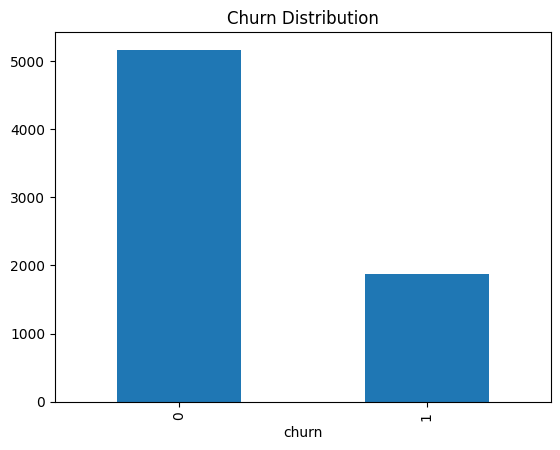

In [ ]:
df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

Observation: About 73% of customers stayed and 27% churned.

Insight: There are more non-churn customers than churn customers.

3. Churn by Contract [Churn across different contract types]

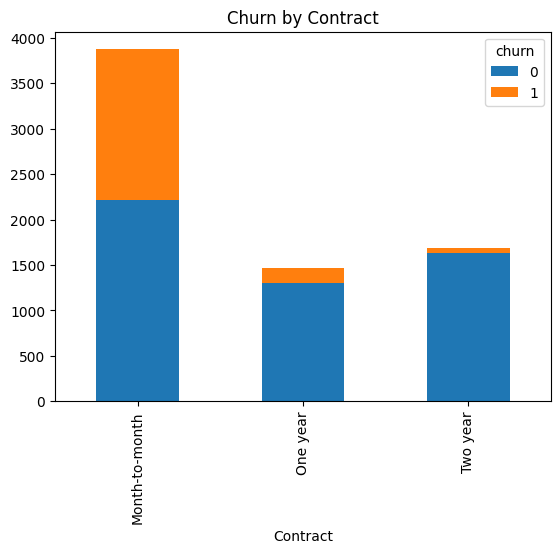

In [ ]:
pd.crosstab(df["Contract"], df["churn"]).plot(kind="bar", stacked=True)
plt.title("Churn by Contract")
plt.show()

Observation: Month-to-month contracts have the highest churn; two-year contracts have the lowest.

Insight: Longer contracts improve customer retention.

4. Tenure Distribution [How long customers stay and helps identify if new customers leave more]

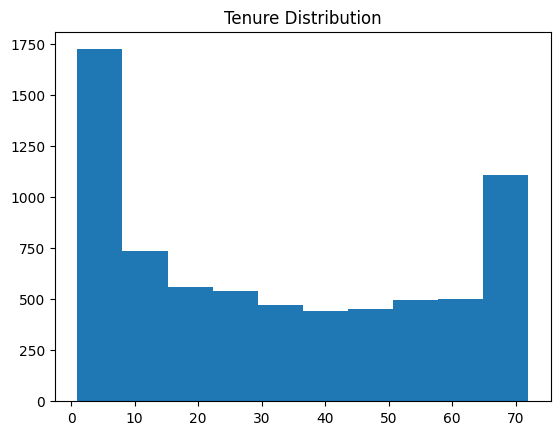

In [ ]:
plt.hist(df['tenure'])
plt.title("Tenure Distribution")
plt.show()

Observation: Customers with lower tenure churn more often.

Insight: New customers are at higher risk of leaving early, indicating the need for strong onboarding and early engagement strategies.

5. Monthly Charges vs Churn [Relationship between price and churn]

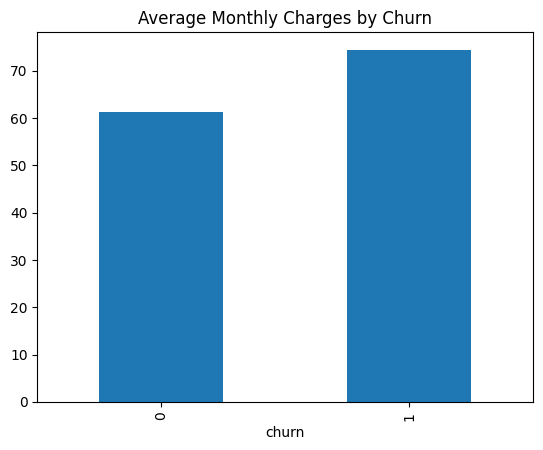

In [ ]:
df.groupby("churn")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Average Monthly Charges by Churn")
plt.show()

Observation: Average monthly charges: churned = 74, retained = 60.

Insight: Higher charges correlate with higher churn.

6. Correlation [factors that are strongly related to churn]

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

correlation = df_encoded.corr()

print(correlation["churn"].sort_values(ascending=False))

churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270



Insight: Loyal, long-term customers stay;
fiber optic users and electronic check payers are more likely to churn.

Prediction Model

---

1. Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("churn", axis=1)
y = df_encoded["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Accuracy

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 78.75%


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[915 118]
 [181 193]]


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



2. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Accuracy

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

Random Forest Accuracy: 78.61%


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))

[[937  96]
 [205 169]]


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



Comparison

In [ ]:
print("Logistic Regression Accuracy:", accuracy * 100)
print("Random Forest Accuracy:", accuracy_rf * 100)

Logistic Regression Accuracy: 78.74911158493248
Random Forest Accuracy: 78.60696517412936


Churn Risk

---



In [143]:
df["Churn_Probability"] = model.predict_proba(X)[:,1]

df["Risk_Level"] = pd.cut(df["Churn_Probability"],
                         bins=[0,0.3,0.7,1],
                         labels=["Low","Medium","High"])

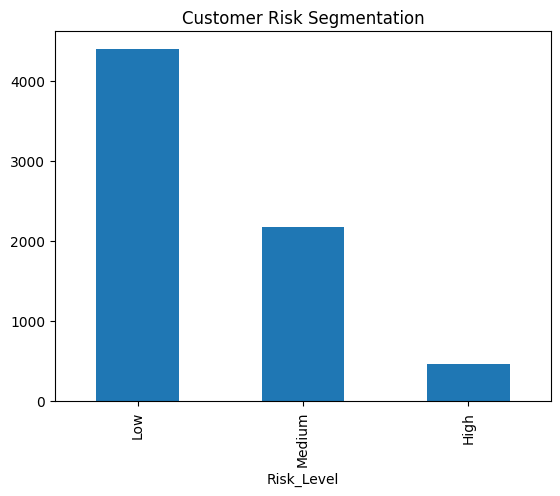

In [146]:
df["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Customer Risk Segmentation")
plt.show()